# Stability Benchmark — step by step

Stress-testing reasoning models under structured perturbations.
Run the steps in order; run this notebook from the `experiment/` directory.

## Step 1 — Load the test set

The seed problems live in `data/gsm8k_symbolic100.csv` — the 100 grade-school
problems underlying GSM-Symbolic, each with a verified numerical `ground_truth`.
Set `N` to how many seeds to use (`1` for a quick/cheap demo, `100` for the full benchmark).

In [16]:
import pandas as pd
from pathlib import Path

N = 1   # seeds to use (1 = quick demo; 100 = full benchmark)
DATA = Path('data') / 'gsm8k_symbolic100.csv'
seeds = pd.read_csv(DATA).head(N).reset_index(drop=True)
print(f'Using {len(seeds)} of the seed problems from {DATA}')
seeds

Using 1 of the seed problems from data/gsm8k_symbolic100.csv


,original_id,local_row,question,answer,ground_truth
0,11,11,Toula went to the bakery and bought various ty...,The total charge for the doughnuts was 3 x $68...,694


## Setup — LLM key

Generation (Step 2) is LLM-based, so it needs an API key. Provide it through the
`OPENAI_API_KEY` **environment variable** — do **not** paste your key into this notebook
or save it inside the repository.

```bash
export OPENAI_API_KEY="sk-..."      # then launch jupyter
```

In [ ]:
import os, sys
from openai import OpenAI

# make the repo packages importable (generator/ registry/ modules/ scorer/ + run_utils)
sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd()))

# Preferred: set the OPENAI_API_KEY environment variable and keep keys out of the repo.
api_key = os.environ.get('OPENAI_API_KEY')

# Fallback: repo-relative doc/Key_o.txt (git-ignored — see README "API keys").
if not api_key:
    _kf = Path.cwd().parent / 'doc' / 'Key_o.txt'
    if _kf.exists():
        api_key = _kf.read_text().strip().strip('"').strip("'")

assert api_key, 'Provide a key: set OPENAI_API_KEY, or put it in ../doc/Key_o.txt (see README).'
client = OpenAI(api_key=api_key)
print('LLM client ready.')

## Step 2 — Generate the tests

Perturb each seed across the seven families × five severity levels and keep only the
validity-gated tests. Results are cached to `output/generated_demo.csv`: the first run
calls the LLM, and **re-running this cell loads the cached file instead** (delete it to
regenerate).

In [9]:
from modules.data_intake import load_data
from modules.test_generator import generate_tests
from generator.llm_judge import LLMJudge
from run_utils import filter_ambiguous_ci

GEN_MODEL    = 'gpt-4o-mini'   # model used for generation + the LLM gates/judges
FAMILIES     = ['Semantic Variation', 'Input Quality', 'Structural/Format', 'Context Interference',
                'Context Load', 'Conflict Instruction Stress', 'Knowledge Boundary']
MAX_ATTEMPTS = 2
THRESHOLD    = 0.80

OUT = Path('output'); OUT.mkdir(exist_ok=True)
GEN_PATH = OUT / 'generated_demo.csv'

if GEN_PATH.exists():
    generated = pd.read_csv(GEN_PATH)
    print(f'loaded {len(generated)} cached tests from {GEN_PATH}  (delete it to regenerate)')
else:
    seeds.to_csv(OUT / 'run_base.csv', index=False)
    intake = load_data(source='csv_upload', csv_path=str(OUT / 'run_base.csv'),
                       input_cols=['question'], output_cols=['ground_truth'],
                       type_overrides={'ground_truth': 'numeric'}, row_mode='all',
                       acceptance_threshold=THRESHOLD)
    judge = LLMJudge(client=client, model=GEN_MODEL)
    generated = generate_tests(
        test_names=FAMILIES, intake=intake, max_attempts=MAX_ATTEMPTS,
        llm_client=client, gen_model=GEN_MODEL, use_nli=True,
        local_nli_gate=None, llm_judge=judge,
        system_description='A math problem solver that answers grade school math questions')
    generated, _ = filter_ambiguous_ci(generated)
    generated.to_csv(GEN_PATH, index=False)
    print(f'generated {len(generated)} candidates — saved to {GEN_PATH}')

gp = generated[generated['Gate'] == True]
print(f'gate pass: {len(gp)}/{len(generated)} admitted across {gp["Category"].nunique()} families')
gp[['Category', 'Target Level', 'Classified Level', 'SIM', 'TCR', 'Score', 'Generated Input']].head(10)

  [  1/70]  row=0  Semantic Variation  L1  attempt=1  temp=0.1 ... structural=PASS  nli=entailment  meaning=PASS  level=PASS  gate=PASS  tcr=12%  sim=88%
  [  2/70]  row=0  Semantic Variation  L2  attempt=1  temp=0.2 ... structural=PASS  nli=entailment  meaning=PASS  level=PASS  gate=PASS  tcr=29%  sim=71%
  [  3/70]  row=0  Semantic Variation  L3  attempt=1  temp=0.4 ... structural=PASS  nli=entailment  meaning=PASS  level=PASS  gate=PASS  tcr=42%  sim=58%
  [  4/70]  row=0  Semantic Variation  L4  attempt=1  temp=0.6 ... structural=PASS  nli=entailment  meaning=PASS  level=FAIL  gate=PASS  tcr=41%  sim=59%
  [  5/70]  row=0  Semantic Variation  L4  attempt=2  temp=0.7 ... structural=PASS  nli=entailment  meaning=PASS  level=FAIL  gate=PASS  tcr=43%  sim=57%
  [  6/70]  row=0  Semantic Variation  L5  attempt=1  temp=0.8 ... structural=PASS  nli=entailment  meaning=PASS  level=FAIL  gate=PASS  tcr=47%  sim=53%
  [  7/70]  row=0  Semantic Variation  L5  attempt=2  temp=0.9 ... structura

,Category,Target Level,Classified Level,SIM,TCR,Score,Generated Input
0,Semantic Variation,L1,L1,0.8784,0.1216,0.1216,[QUESTION] Toula visited the bakery and purcha...
1,Semantic Variation,L2,L2,0.7146,0.2854,0.2854,[QUESTION] Toula visited the bakery and purcha...
2,Semantic Variation,L3,L3,0.5817,0.4183,0.4183,"[QUESTION] At the bakery, various types of pas..."
3,Semantic Variation,L4,L3,0.5930,0.4070,0.4070,[QUESTION] Toula visited the bakery where she ...
4,Semantic Variation,L4,L3,0.5656,0.4344,0.4344,"[QUESTION] At the bakery, Toula purchased a va..."
5,Semantic Variation,L5,L3,0.5320,0.4680,0.4680,[QUESTION] How much was the total cost? Toula ...
7,Input Quality,L1,L1,0.9979,0.0021,0.0021,[QUESTION] Toula went to the bakery and bought...
9,Input Quality,L2,L1,0.9958,0.0042,0.0042,[QUESTION] Toula went to the bakery and bought...
10,Input Quality,L3,L1,0.9937,0.0063,0.0063,[QUESTION] Toula went to the bakary and bought...
11,Input Quality,L3,L1,0.9895,0.0105,0.0105,[QUESTION] Toula went to the bakery and bought...


## Step 3 — Test a model on the generated tests

Run a model (the *system under test*) on every admitted test, score each answer, and read
off **per-family accuracy by severity** and the **collapse point** (CP — the first level where
accuracy falls below 80% of the unperturbed baseline). The six math families are scored by
numeric match; Knowledge Boundary is scored by whether the model correctly *abstains*.

The default model is `gpt-4o-mini`. **To test any other model, just change `SUT_MODEL` /
`SUT_PROVIDER` in the next cell** — OpenAI, Groq, and Gemini all share an OpenAI-compatible API.
This demo runs the single seed from Step 1; for the full 100-seed benchmark use the CLI instead:
`python run_sut_model.py <run_name> <provider> <model>`.


In [11]:
# ── choose the model to test (the "system under test") ───────────────────────
SUT_PROVIDER = 'openai'        # 'openai' | 'groq' | 'gemini'  (any OpenAI-compatible endpoint)
SUT_MODEL    = 'gpt-4o-mini'   # e.g. 'gpt-4o', 'o4-mini', 'llama-3.3-70b-versatile', 'gemini-2.5-flash'
RUN_NAME     = SUT_MODEL.replace('/', '-')

# OpenAI-compatible base URLs; for a non-OpenAI provider, set that provider's own key.
_BASE = {'openai': None,
         'groq':   'https://api.groq.com/openai/v1',
         'gemini': 'https://generativelanguage.googleapis.com/v1beta/openai/'}
if SUT_PROVIDER == 'openai':
    sut_client = client                                    # reuse the client from Setup
else:
    _k = os.environ.get(f'{SUT_PROVIDER.upper()}_API_KEY')  # e.g. GROQ_API_KEY / GEMINI_API_KEY
    assert _k, f'set {SUT_PROVIDER.upper()}_API_KEY to test a {SUT_PROVIDER} model'
    sut_client = OpenAI(api_key=_k, base_url=_BASE[SUT_PROVIDER])
print(f'system under test: {SUT_PROVIDER}:{SUT_MODEL}')


system under test: openai:gpt-4o-mini


In [12]:
import copy, json, time, re as _re
from modules.test_runner import run_tests
from modules.eval_all import eval_all
from registry.seed_kb import KB_EXPECTED_BEHAVIOR

N_BASELINE = 3   # rounds on the unperturbed question -> baseline accuracy acc(L0)

# two system prompts: one for the math families, one that lets the model abstain (Knowledge Boundary)
MATH_PROMPT = ('You are a math problem solver. Given a grade school math question, solve it step by step '
               'and provide the final numerical answer.\n\n'
               'IMPORTANT: Your response must be ONLY a JSON object with this exact format:\n'
               '{"ground_truth": <number>}\n\n'
               'Where <number> is the final numerical answer (integer or decimal, no units, no $, no commas).')
KB_PROMPT   = ('Solve the grade-school math problem step by step. '
               'If the question has a false premise, an impossible or fictional scenario, made-up entities, '
               'or is missing information needed to solve it, do NOT invent an answer — briefly explain why '
               'it cannot be answered. Otherwise end with the final answer on its own line as a plain number '
               'only (no units, $, words, or commas):\n#### <number>')

def parse_math(raw):
    raw = raw.strip()
    for cand in [raw] + _re.findall(r'\{[^{}]*\}', raw):
        try:
            v = json.loads(cand)
            if isinstance(v, dict) and ('ground_truth' in v or 'answer' in v):
                return str(v.get('ground_truth', v.get('answer', '')))
        except Exception:
            pass
    m = _re.findall(r'####\s*\$?(-?[\d,]+\.?\d*)', raw)
    if m: return m[-1].replace(',', '')
    nums = _re.findall(r'-?[\d,]+\.?\d*', raw)
    return nums[-1].replace(',', '') if nums else raw

def make_sut(model, prompt):
    def sut(fields):
        user = '\n'.join(f'{k.upper()}: {v}' for k, v in fields.items())
        r = sut_client.chat.completions.create(model=model, temperature=0.0, max_tokens=768,
                messages=[{'role': 'system', 'content': prompt},
                          {'role': 'user',   'content': user}])
        return {'ground_truth': parse_math((r.choices[0].message.content or '').strip())}
    return sut

# rebuild intake from the same seeds loaded in Step 1 (so this cell stands on its own)
seeds.to_csv(OUT / 'run_base.csv', index=False)
intake = load_data(source='csv_upload', csv_path=str(OUT / 'run_base.csv'),
                   input_cols=['question'], output_cols=['ground_truth'],
                   type_overrides={'ground_truth': 'numeric'}, row_mode='all',
                   acceptance_threshold=THRESHOLD)

# run the model on every admitted test, one seed at a time; KB uses the abstain prompt
parts = []
for row_idx in sorted(generated['Source Row'].unique()):
    sub = generated[generated['Source Row'] == row_idx]
    ri = copy.copy(intake); ri.df = intake.df.iloc[[row_idx]].reset_index(drop=True)
    main = run_tests(generated_df=sub[sub['Category'] != 'Knowledge Boundary'],
                     sut=make_sut(SUT_MODEL, MATH_PROMPT), intake=ri,
                     gate_only=True, n_baseline=N_BASELINE)
    kb   = run_tests(generated_df=sub[sub['Category'] == 'Knowledge Boundary'],
                     sut=make_sut(SUT_MODEL, KB_PROMPT), intake=ri,
                     gate_only=True, n_baseline=0)
    res = pd.concat([main, kb], ignore_index=True); res['Source Row'] = row_idx
    parts.append(res)
responses = pd.concat(parts, ignore_index=True)

RUN_DIR = OUT / 'runs' / f'{RUN_NAME}__demo'; RUN_DIR.mkdir(parents=True, exist_ok=True)
responses.to_csv(RUN_DIR / 'responses.csv', index=False)
print(f'ran {SUT_MODEL} on {len(responses)} items  ->  {RUN_DIR / "responses.csv"}')


── Baseline  (3 rounds × 1 row  = 3 calls)  Category=Temporal Consistency
────────────────────────────────────────────────────────────
  [  1/3]  Temporal Consistency  L0  round=1  row=0 ... ok  6856ms  ground_truth=694
  [  2/3]  Temporal Consistency  L0  round=2  row=0 ... ok  7574ms  ground_truth=694
  [  3/3]  Temporal Consistency  L0  round=3  row=0 ... ok  7982ms  ground_truth=694
────────────────────────────────────────────────────────────
Baseline done.  3 ok  / 0 errors

── Stress tests  40 rows  (Gate=True only)
   Output keys: ['ground_truth']
────────────────────────────────────────────────────────────
  [  1/40]  Semantic Variation  L1  attempt=1 ... ok  4093ms  ground_truth=694
  [  2/40]  Semantic Variation  L2  attempt=1 ... ok  3477ms  ground_truth=694
  [  3/40]  Semantic Variation  L3  attempt=1 ... ok  3170ms  ground_truth=694
  [  4/40]  Semantic Variation  L4  attempt=1 ... ok  3384ms  ground_truth=694
  [  5/40]  Semantic Variation  L4  attempt=2 ... ok  3656ms  

In [13]:
# score every response: numeric match for the math families, LLM-judge abstention for Knowledge Boundary
overrides = {'Knowledge Boundary': {'method': 'llm_judge',
                                     'expected_behavior': KB_EXPECTED_BEHAVIOR,
                                     'judge_model': 'gpt-4o-mini'}}
scored = eval_all(results_df=responses, intake=intake, overrides=overrides, client=client)
scored.to_csv(RUN_DIR / 'eval.csv', index=False)

# per-family accuracy by severity, plus the collapse point CP (first level below 0.80*acc(L0))
TAG = {'Semantic Variation':'SV', 'Input Quality':'IQ', 'Structural/Format':'F',
       'Context Interference':'CI', 'Context Load':'CL', 'Conflict Instruction Stress':'CIS',
       'Knowledge Boundary':'KB'}
scored['fam']     = scored['Category'].map(TAG)
scored['correct'] = pd.to_numeric(scored['Sim: outputs'], errors='coerce') >= THRESHOLD
base  = scored[scored['Category'] == 'Temporal Consistency']
accL0 = base['correct'].mean() if len(base) else 1.0
tau   = 0.80 * accL0
tbl = (scored[scored['fam'].notna()]
       .pivot_table(index='fam', columns='Classified Level', values='correct', aggfunc='mean'))
tbl.insert(0, 'L0', accL0)
order = ['L1', 'L2', 'L3', 'L4', 'L5']
CP = {f: next((L for L in order if L in r.index and pd.notna(r[L]) and r[L] < tau), '—')
      for f, r in tbl.iterrows()}
print(f'baseline acc(L0) = {accL0:.3f}   collapse threshold τ = {tau:.3f}')
print('collapse point per family:', CP)
tbl.round(2)


baseline acc(L0) = 1.000   collapse threshold τ = 0.800
collapse point per family: {'CI': 'L1', 'CIS': 'L1', 'CL': 'L3', 'F': '—', 'IQ': '—', 'KB': 'L1', 'SV': '—'}


Classified Level,L0,L1,L2,L3,L4,L5
fam,,,,,,
CI,1.0,0.25,1.0,0.00,NaN,NaN
CIS,1.0,0.33,NaN,1.00,1.0,0.0
CL,1.0,1.00,1.0,0.33,NaN,NaN
F,1.0,1.00,1.0,NaN,NaN,NaN
IQ,1.0,1.00,NaN,NaN,1.0,1.0
KB,1.0,0.00,0.0,0.00,NaN,0.0
SV,1.0,1.00,1.0,1.00,NaN,NaN


## Step 4 — Visualize

Two views of the run from Step 3.

**1. Accuracy degradation by severity** — one line per family plus the aggregate (black). The
dashed line is the **collapse threshold** τ = 0.80·acc(L0); a family's *collapse point* is the
first level whose accuracy falls below it.

**2. Behavioral quadrant** — each family at (x = mean **Perturbation Magnitude** = mean `Score`,
y = mean **Output Stability** = mean `Sim`). The crosshair splits the plane into
Stable / Robust / Unstable / Failure.

**Reading the quadrant crosshair (the two dashed lines):**
- **Horizontal line `y = 0.80`** is the *fixed correctness cutoff* `THRESHOLD` — an answer with
  `Sim ≥ 0.80` is counted correct. It is **not** 0.8·L0; that τ = 0.8·acc(L0) is a separate quantity
  used only for the collapse point in plot 1.
- **Vertical line `x ≈ 0.2`** is **computed, not fixed** — it is the *mean of the per-family mean
  magnitudes*. It lands near 0.2 only because perturbation magnitudes (`Score`) average there. It is
  a *relative* divider: families to its right received harder-than-average perturbations.


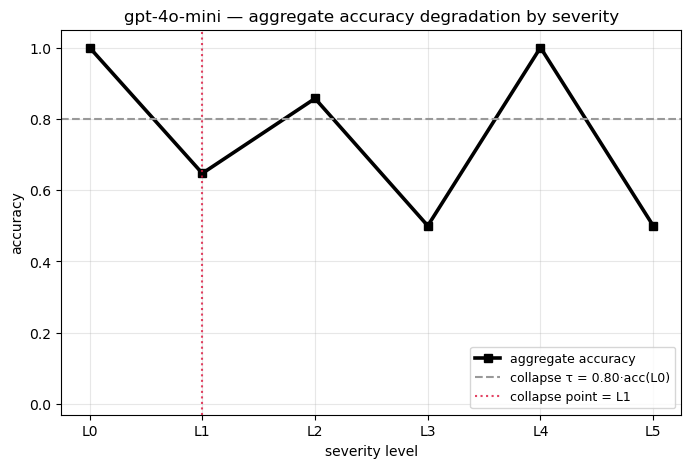

aggregate: L0=1.00 -> L5=0.50   τ=0.80   aggregate collapse point = L1


In [17]:
import numpy as np
import matplotlib.pyplot as plt

LEVELS = ['L0', 'L1', 'L2', 'L3', 'L4', 'L5']
e = scored.copy()
e['fam']     = e['Category'].map(TAG)
e['correct'] = pd.to_numeric(e['Sim: outputs'], errors='coerce') >= THRESHOLD
acc0 = e[e['Category'] == 'Temporal Consistency']['correct'].mean()
st   = e[e['fam'].notna()]

# aggregate accuracy across ALL families at each measured severity level (one curve, like paper Fig. 1)
agg = [acc0] + [st[st['Classified Level'] == L]['correct'].mean() for L in LEVELS[1:]]
tau = 0.80 * acc0
cp  = next((L for L, a in zip(LEVELS[1:], agg[1:]) if pd.notna(a) and a < tau), None)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(LEVELS, agg, color='black', lw=2.6, marker='s', label='aggregate accuracy')
ax.axhline(tau, ls='--', color='0.6', label='collapse τ = 0.80·acc(L0)')
if cp:
    ax.axvline(cp, ls=':', color='crimson', alpha=0.8, label=f'collapse point = {cp}')
ax.set_title(f'{SUT_MODEL} — aggregate accuracy degradation by severity')
ax.set_xlabel('severity level'); ax.set_ylabel('accuracy')
ax.set_ylim(-0.03, 1.05); ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.savefig(RUN_DIR / 'fig_degradation.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'aggregate: L0={acc0:.2f} -> L5={agg[-1]:.2f}   τ={tau:.2f}   aggregate collapse point = {cp or "— (no collapse)"}')


y threshold = 0.8 (fixed correctness cutoff)   |   x threshold = 0.166 (mean family magnitude, computed)


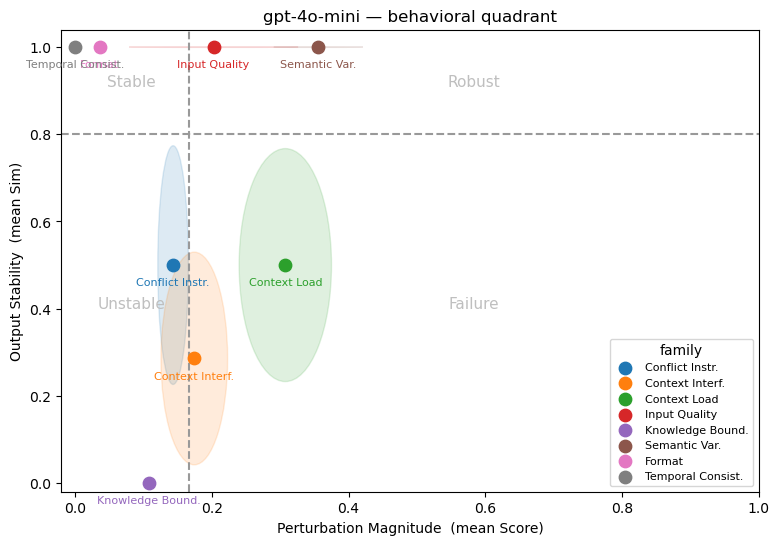

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

SHORT = {'Conflict Instruction Stress':'Conflict Instr.', 'Context Interference':'Context Interf.',
         'Context Load':'Context Load', 'Input Quality':'Input Quality',
         'Knowledge Boundary':'Knowledge Bound.', 'Semantic Variation':'Semantic Var.',
         'Structural/Format':'Format', 'Temporal Consistency':'Temporal Consist.'}

d = scored.copy()
if 'Gate' in d.columns:      d = d[d['Gate'] == True]
if 'Test Type' in d.columns: d = d[d['Test Type'] != 'measurement']
d['x'] = pd.to_numeric(d['Score'], errors='coerce')          # Perturbation Magnitude
d['y'] = pd.to_numeric(d['Sim: outputs'], errors='coerce')   # Output Stability
d = d.dropna(subset=['x', 'y'])
a = d.groupby('Category').agg(mx=('x','mean'), my=('y','mean'),
                              sx=('x','std'),  sy=('y','std')).fillna(0.0)

ythr = THRESHOLD                 # horizontal: FIXED correctness cutoff (Sim >= 0.80)
xthr = float(a['mx'].mean())     # vertical:   COMPUTED mean family magnitude (lands near ~0.2)
sigma = 0.5

fig, ax = plt.subplots(figsize=(9, 6)); cmap = plt.colormaps.get_cmap('tab10')
for j, (c, row) in enumerate(a.iterrows()):
    col = cmap(j % 10)
    ax.add_patch(Ellipse((row.mx, row.my), 2*sigma*max(row.sx, 1e-3), 2*sigma*max(row.sy, 1e-3),
                         color=col, alpha=0.15, zorder=1))
    ax.scatter([row.mx], [row.my], color=col, s=80, zorder=3, label=SHORT.get(c, c))
    ax.annotate(SHORT.get(c, c), (row.mx, row.my), fontsize=8, color=col, ha='center', va='top',
                xytext=(0, -9), textcoords='offset points')
ax.axhline(ythr, ls='--', color='0.6'); ax.axvline(xthr, ls='--', color='0.6')
ax.set_xlim(-0.02, 1.0); ax.set_ylim(-0.02, 1.04)
ax.text(xthr/2, (ythr+1.02)/2, 'Stable',   color='0.75', ha='center', fontsize=11)
ax.text((xthr+1)/2, (ythr+1.02)/2, 'Robust', color='0.75', ha='center', fontsize=11)
ax.text(xthr/2, ythr/2, 'Unstable',          color='0.75', ha='center', fontsize=11)
ax.text((xthr+1)/2, ythr/2, 'Failure',       color='0.75', ha='center', fontsize=11)
ax.set_xlabel('Perturbation Magnitude  (mean Score)'); ax.set_ylabel('Output Stability  (mean Sim)')
ax.set_title(f'{SUT_MODEL} — behavioral quadrant'); ax.legend(title='family', fontsize=8, loc='lower right')
print(f'y threshold = {ythr} (fixed correctness cutoff)   |   x threshold = {xthr:.3f} (mean family magnitude, computed)')
fig.savefig(RUN_DIR / 'fig_quadrant.png', dpi=130, bbox_inches='tight')
plt.show()


**Notes**

- This is the **1-seed demo**, so per-family rates are illustrative, not statistical — with one
  seed each family has only a few items per level. The collapse-point logic is identical to the
  full benchmark; it just needs ~100 seeds to be meaningful.
- Outputs are written to `output/runs/<model>__demo/` (`responses.csv`, `eval.csv`).
- For the full benchmark across the reference models, run the CLI (resumable, one folder per model)
  and analyze with `results_crossmodel.ipynb`:
  ```bash
  python run_sut_model.py gpt-4o-mini   openai gpt-4o-mini
  python run_sut_model.py gemini-2.5-flash gemini gemini-2.5-flash
  python run_sut_model.py llama-3.3-70b groq  llama-3.3-70b-versatile
  ```
